# Demo 4 Frequency Shift

We want to simulate a frequency shiftting ring-down signal.

In [4]:
import sys
from pathlib import Path
repo_root = Path.cwd().parent   # demo/data → demo → browniansim/
sys.path.insert(0, str(repo_root))
import browniansim as bs
import function as fc
import numpy as np
import matplotlib.pyplot as plt

# Oscillating Pulse

Consider shiftting the frequency of Cantlever by dw*w0, where w0 is cantilever's resonant frequecny.
$\frac{d^2x}{d\tau^2}+\frac{1}{Q}\frac{dx}{d\tau}+(1+dw)^2x =0$



It is a freq-shift ring-down movement

# Square waves

In [ ]:
def square_pulse(tau_l,dtau,pulse_length,dw):
    '''
    Generate a square wave with a pulse length of pulse_length and a frequency shift of dw 
    Parameters:
        tau_l: np.ndarray, time series
        dtau: float, time step
        pulse_length: float, pulse length
        dw: float, frequency shift
    Returns:
        wave: np.ndarray, square wave
    '''
    square_wave = np.zeros_like(tau_l, dtype=float)
    samples_per_pulse = int(np.round(pulse_length / dtau))
    for i in range(len(tau_l)):
        if (i // samples_per_pulse) % 2 == 0:
            square_wave[i] = dw
        else:
            square_wave[i] = 0
    return square_wave



In [19]:
l = np.array([0,1,2,3,4,])
l = l[1:]
np.append(l,l[-1])


array([1, 2, 3, 4, 4])

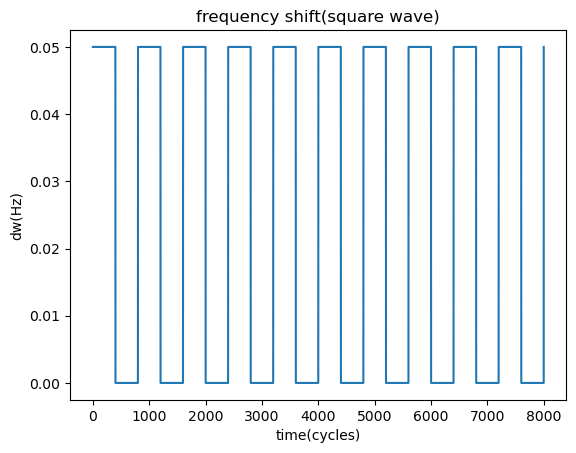

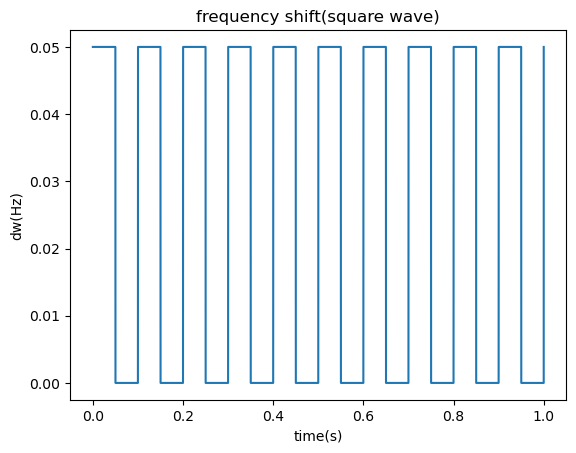

In [21]:
dtau = 0.05*2*np.pi #our sampling rate is about 200kHz, w0 is about 8k, so about 20 times bigger

n = 8000.3 # number of cycles in each pulse
dw_l = np.zeros((int(n*2*np.pi/dtau),4))#w = 1+dw
tau_l = np.arange(0,len(dw_l)*dtau,dtau)
X0_0 = [1,0]# initial displacement and velocity for simulation
Q=10000
w0 = 8000*2*np.pi
dw = 0.05/w0*2*np.pi# we need to set the efficient rad freq for eacxh set, w_eff = 1+dw, and real rad freq w(t) = w0*w_eff = w0*(1+dw)\
freq_freqShift = 10 # the freq of freq shift(Hz)
pulse_length = 1/freq_freqShift/2*w0 # the length of the pulse is the period of the freq shift, note that tau = t*w0
dw_l = square_pulse(tau_l,dtau,pulse_length,dw)
dw_l = np.array([dw_l,np.append(dw_l[1:],dw_l[-1]),np.append(dw_l[1:],dw_l[-1]),np.append(dw_l[1:],dw_l[-1])]).T

plt.plot(tau_l/2/np.pi,dw_l[:,0]*w0/2/np.pi)
plt.xlabel('time(cycles)')
plt.ylabel('dw(Hz)')
plt.title('frequency shift(square wave)')
plt.show()

plt.plot(tau_l/w0,dw_l[:,0]*w0/2/np.pi)
plt.xlabel('time(s)')
plt.ylabel('dw(Hz)')
plt.title('frequency shift(square wave)')
plt.show()



# Simulation

In [25]:
dtau = 0.05*2*np.pi #our sampling rate is about 200kHz, w0 is about 8k, so about 20 times bigger

n = 8000.3 # number of cycles in each pulse, making simulation time to be 1s
dw_l = np.zeros((int(n*2*np.pi/dtau),4))#w = 1+dw
tau_l = np.arange(0,len(dw_l)*dtau,dtau)
X0_0 = [1,0]# initial displacement and velocity for simulation
Q=10000
w0 = 8000*2*np.pi
dw = 0.05/w0*2*np.pi# we need to set the efficient rad freq for eacxh set, w_eff = 1+dw, and real rad freq w(t) = w0*w_eff = w0*(1+dw)\
freq_freqShift = 10 # the freq of freq shift(Hz)
pulse_length = 1/freq_freqShift*w0 # the length of the pulse is the period of the freq shift, note that tau = t*w0
dw_l = square_pulse(tau_l,dtau,pulse_length,dw)
dw_l_sim = np.array([dw_l,np.append(dw_l[1:],dw_l[-1]),np.append(dw_l[1:],dw_l[-1]),np.append(dw_l[1:],dw_l[-1])]).T
F = np.zeros((len(dw_l),4))
t_l =tau_l/w0
signal_freqShift = bs.solve_RK4(X0_0, dtau, Q, F,dw_l_sim)






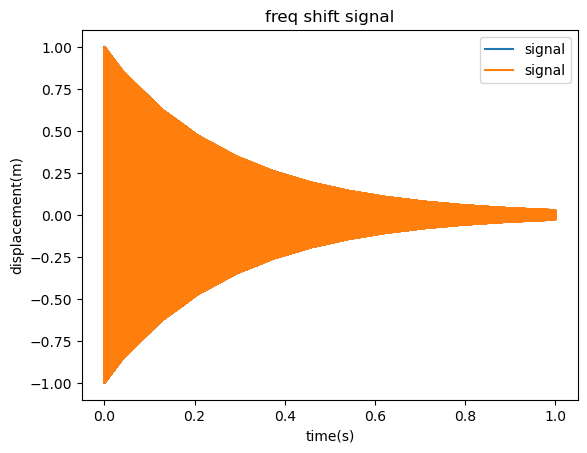

In [26]:
plt.plot(t_l,signal_freqShift,label='signal')
plt.xlabel('time(s)')
plt.ylabel('displacement(m)')
plt.title('freq shift signal')
plt.legend()
plt.show()


# Extracting freq



In [27]:
def getCantileverFreq(
    data,
    t_cycle, 
    t_rip, 
    dt_chunk_target=221.34e-6, 
    bpstyle="gaussian"
):
    '''
    This function is used to apply a Hilbert filter to a signal, then fit the phase vs. time data, and compute the frequency.
    Parameters:
        data[array]:2D array, the first column is the time, the second column is the signal.
        t_cycle[float]: the cyclize time of the signal.
        f_band[float]: the bandpass width,unit is kHz.
        t_rip[float]: the ripple time of the signal.
        dt_chunk_target[float]: the target chunk time of the frequency signal.
        bpstyle: the style of the bandpass filter. 
    Returns:
        avg_fc[float]: the frequency signal.
    '''

    # create numpy array from incoming waveform
    arr = np.array(data)
    # extract ordinate data array
    x, y = arr[:, 0], arr[:, 1]
    # time step
    dt = x[1] - x[0]
    # apply time mask
    # x, y = time_mask_binarate(x, y, dt, "middle")
    # force data to start/end at zero, prevent edge effect on the beginning and end of the signal
    w = fc.time_window_cyclicize(x, y, dt, t_cycle)
    # apply cyclicizing window to signal
    y = y * w
    # fourier transform (F.T.)
    freq, sFT = fc.fft(x, y, dt)
    # complex Hilbert transform
    filt = fc.freq_filter_Hilbert_complex(freq, sFT)
    # apply 1kHz wide bandpass filter
    bp = fc.freq_filter_bp(freq, sFT, filt, 1.00, style=bpstyle)
    # set up filter to remove ripples
    mask, x_rippleless = fc.time_mask_rippleless(x, dt, t_rip)
    # Inverse F.T.
    sIFT, p, a = fc.ifft(sFT, dt, filt, bp, mask)
    # fit phase vs. time data
    x_sub_middle, slope = fc.fit_phase(sIFT, p, a, dt, x, dt_chunk_target)
    # compute average fc
    avg_fc = np.mean(slope)

    return slope

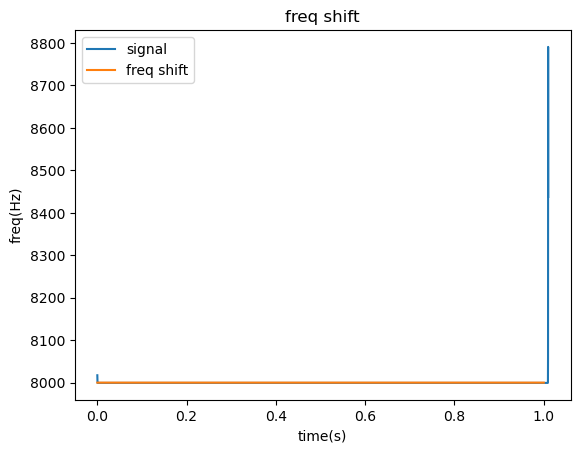

In [28]:
t_rip = 0# s, time of the ripple of our signal
t_cycle = 1e-4# s, time of the window cycle of our signal
dt_chunk_target = 221e-6#s, target chunk time of the frequency signal
t_freqshift_l = np.arange(0,len(signal_freqShift[:,0])*dtau/w0,dtau/w0)
data = np.array([t_freqshift_l,signal_freqShift[:,0]]).T

freq_sig = getCantileverFreq(data,t_cycle,t_rip,dt_chunk_target)
t_freq_signal = np.arange(0,len(freq_sig)*dt_chunk_target,dt_chunk_target)
plt.plot(t_freq_signal,freq_sig,label='signal')
plt.plot(tau_l/w0,dw_l*w0/2/np.pi+w0/2/np.pi,label = 'freq shift')
plt.plot()
plt.xlabel('time(s)')
plt.ylabel('freq(Hz)')
plt.title('freq shift')
plt.legend()
plt.show()



There are big erro in the beginning and the end of our signa, let's get for of some signal in the beginning and the end of our signal

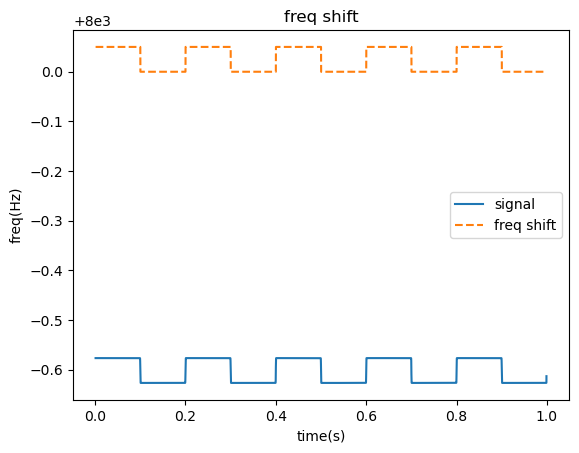

In [29]:
t_ripp = 10.5e-4# s, time of the ripple of our signal
t_cycle = 2e-4# s, time of the window cycle of our signal
dt_chunk_target = dtau/w0*10#s, target chunk time of the frequency signal
t_freqshift_l = np.arange(0,len(signal_freqShift[:,0])*dtau/w0,dtau/w0)
data = np.array([t_freqshift_l,signal_freqShift[:,0]]).T

freq_sig = getCantileverFreq(data,t_cycle,0,dt_chunk_target)
t_freq_signal = np.arange(0,len(freq_sig)*dt_chunk_target,dt_chunk_target)

i_ripp_fs = int(t_ripp/dtau*w0)
i_ripp_sig = int(t_ripp/dt_chunk_target)
plt.plot(t_freq_signal[i_ripp_sig:-i_ripp_sig],freq_sig[i_ripp_sig:-i_ripp_sig],label='signal')
plt.plot(tau_l[i_ripp_fs:-i_ripp_fs]/w0,dw_l[i_ripp_fs:-i_ripp_fs]*w0/2/np.pi+w0/2/np.pi,label = 'freq shift',linestyle='--')
plt.plot()
plt.xlabel('time(s)')
plt.ylabel('freq(Hz)')
plt.title('freq shift')
plt.legend()
plt.show()

Well, it seems that our freq extractordon't have a good estimation of w0, but dw seems to be right, lets do a fft to check this

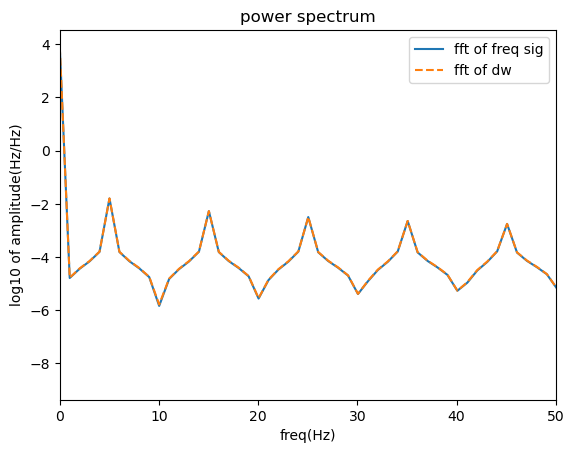

In [30]:
sig_f_fft = np.fft.fft(freq_sig[i_ripp_sig:-i_ripp_sig])
sig_f_fft_abs = sig_f_fft / len(freq_sig[i_ripp_sig:-i_ripp_sig])
sig_f_fft_freqs = np.fft.fftfreq(len(freq_sig[i_ripp_sig:-i_ripp_sig]), d=dt_chunk_target)

dw_fft = np.fft.fft(dw_l[i_ripp_fs:-i_ripp_fs]*w0/2/np.pi+w0/2/np.pi)
dw_fft_abs = dw_fft / len(dw_l[i_ripp_fs:-i_ripp_fs]*w0/2/np.pi+w0/2/np.pi)
dw_fft_freqs = np.fft.fftfreq(len(dw_l[i_ripp_fs:-i_ripp_fs]*w0/2/np.pi+w0/2/np.pi), d=dtau/w0)

plt.plot(sig_f_fft_freqs[:len(sig_f_fft_freqs)//2],np.log10(np.abs(sig_f_fft_abs)[:len(sig_f_fft_freqs)//2]),label='fft of freq sig')
plt.plot(dw_fft_freqs[:len(dw_fft_freqs)//2],np.log10(np.abs(dw_fft_abs[:len(dw_fft_freqs)//2])),label = 'fft of dw',linestyle = '--')

plt.xlim(0,50)
plt.xlabel('freq(Hz)')
plt.ylabel('log10 of amplitude(Hz/Hz)')
plt.legend()
plt.title('power spectrum')
plt.show()

Nice, lets varing parameters

# Freuency of freq shift

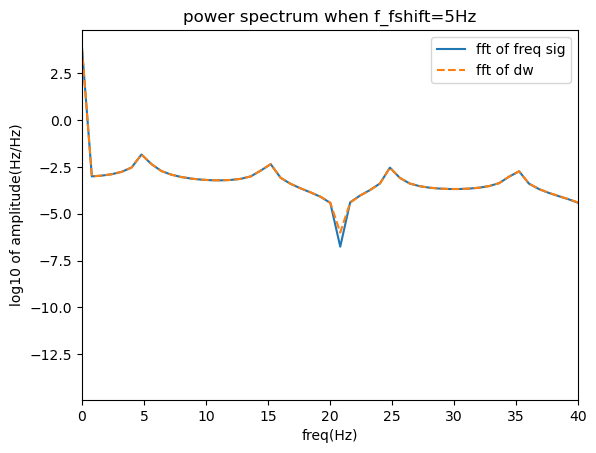

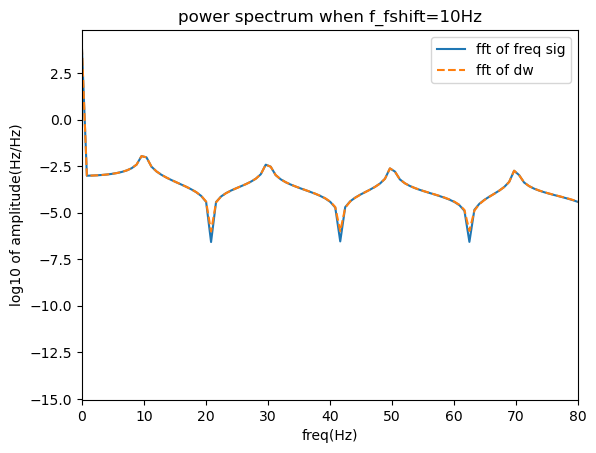

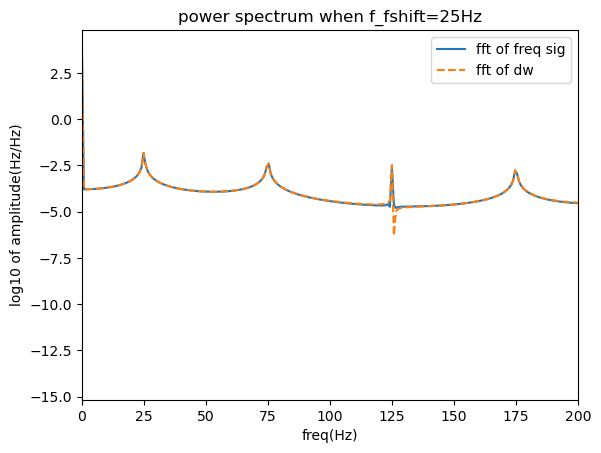

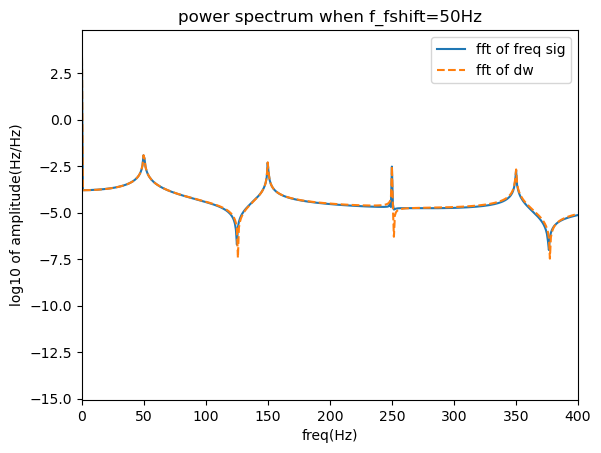

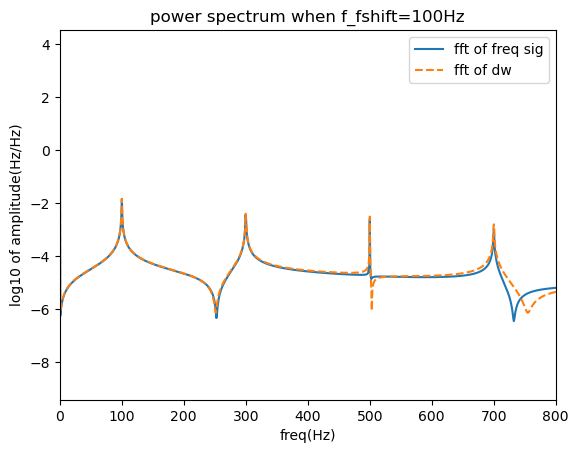

In [32]:
freq_freqShift_l = [5,10,25,50,100] # the freq of freq shift(Hz)

dtau = 0.05*2*np.pi #our sampling rate is about 200kHz, w0 is about 8k, so about 20 times bigger
n = 10000.3 # number of cycles in each pulse, making simulation time to be 1s
dw_l = np.zeros(int(n*2*np.pi/dtau))#w = 1+dw
tau_l = np.arange(0,len(dw_l)*dtau,dtau)
X0_0 = [1,0]# initial displacement and velocity for simulation
Q=20000
w0 = 8000*2*np.pi
dw = 0.05/w0*2*np.pi# we need to set the efficient rad freq for eacxh set, w_eff = 1+dw, and real rad freq w(t) = w0*w_eff = w0*(1+dw)\

for freq_freqShift in freq_freqShift_l:

    pulse_length = 1/freq_freqShift/2*w0 # the length of the pulse is the period of the freq shift, note that tau = t*w0
    dw_l = square_pulse(tau_l,dtau,pulse_length,dw)
    dw_l_sim = np.array([dw_l,np.append(dw_l[1:],dw_l[-1]),np.append(dw_l[1:],dw_l[-1]),np.append(dw_l[1:],dw_l[-1])]).T
    F = np.zeros((len(dw_l),4))
    t_l =tau_l/w0
    signal_freqShift = bs.solve_RK4(X0_0, dtau, Q, F,dw_l_sim)
    
    t_rip = 10e-4# s, time of the ripple of our signal
    t_cycle = 1e-4# s, time of the window cycle of our signal
    dt_chunk_target =  0.05*2*np.pi*10/w0#s, target chunk time of the frequency signal
    t_freqshift_l = np.arange(0,len(signal_freqShift[:,0])*dtau/w0,dtau/w0)
    data = np.array([t_freqshift_l,signal_freqShift[:,0]]).T

    freq_sig = getCantileverFreq(data,t_cycle,0,dt_chunk_target)
    t_freq_signal = np.arange(0,len(freq_sig)*dt_chunk_target,dt_chunk_target)

    sig_f_fft = np.fft.fft(freq_sig[i_ripp_sig:-i_ripp_sig])
    sig_f_fft_abs = sig_f_fft / len(freq_sig[i_ripp_sig:-i_ripp_sig])
    sig_f_fft_freqs = np.fft.fftfreq(len(freq_sig[i_ripp_sig:-i_ripp_sig]), d=dt_chunk_target)

    dw_fft = np.fft.fft(dw_l[i_ripp_fs:-i_ripp_fs]*w0/2/np.pi+w0/2/np.pi)
    dw_fft_abs = dw_fft / len(dw_l[i_ripp_fs:-i_ripp_fs]*w0/2/np.pi+w0/2/np.pi)
    dw_fft_freqs = np.fft.fftfreq(len(dw_l[i_ripp_fs:-i_ripp_fs]*w0/2/np.pi+w0/2/np.pi), d=dtau/w0)

    plt.plot(sig_f_fft_freqs[:len(sig_f_fft_freqs)//2],np.log10(np.abs(sig_f_fft_abs)[:len(sig_f_fft_freqs)//2]),label='fft of freq sig')
    plt.plot(dw_fft_freqs[:len(dw_fft_freqs)//2],np.log10(np.abs(dw_fft_abs[:len(dw_fft_freqs)//2])),label = 'fft of dw',linestyle = '--')

    plt.xlim(0,freq_freqShift*8)
    plt.xlabel('freq(Hz)')
    plt.ylabel('log10 of amplitude(Hz/Hz)')
    plt.legend()
    plt.title('power spectrum when f_fshift='+str(freq_freqShift)+'Hz')
    plt.show()

# amplitude of freq shift

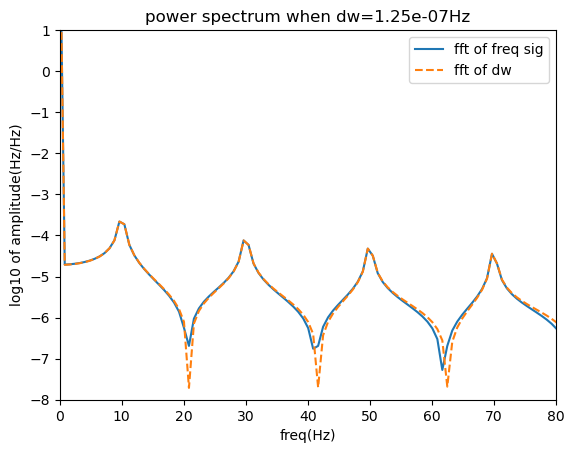

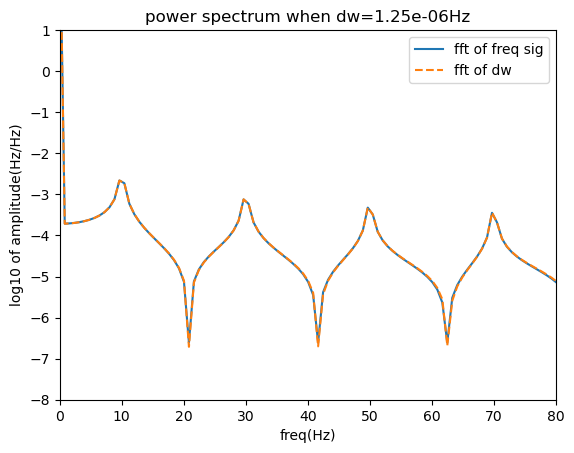

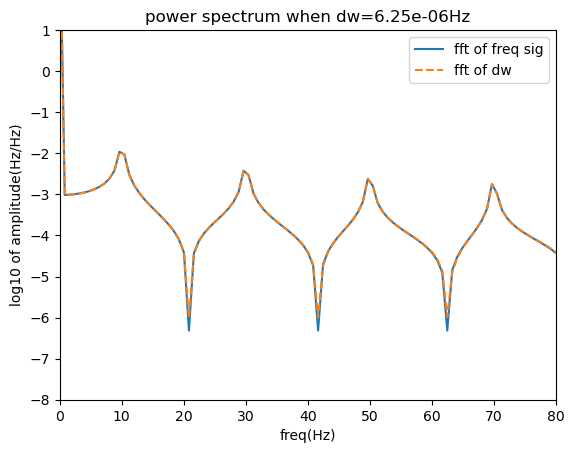

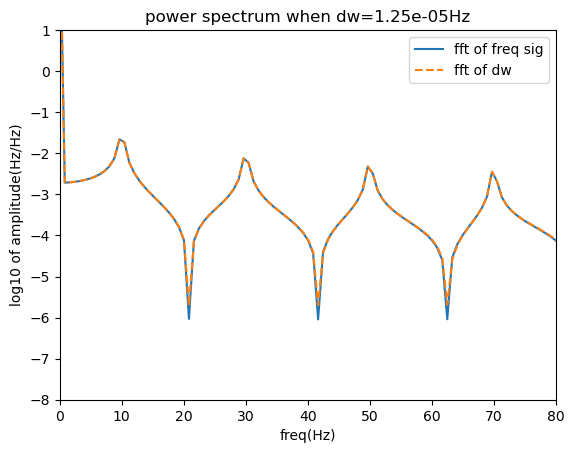

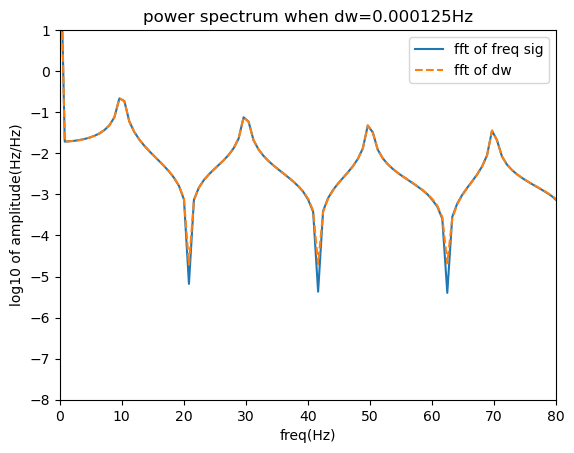

In [64]:
freq_freqShift=10 # the freq of freq shift(Hz)

dtau = 0.05*2*np.pi #our sampling rate is about 200kHz, w0 is about 8k, so about 20 times bigger
n = 10000.3 # number of cycles in each pulse, making simulation time to be 1s
dw_l = np.zeros(int(n*2*np.pi/dtau))#w = 1+dw
tau_l = np.arange(0,len(dw_l)*dtau,dtau)
X0_0 = [1,0]# initial displacement and velocity for simulation
Q=20000
w0 = 8000*2*np.pi
dw_list = [0.001/w0*2*np.pi,0.01/w0*2*np.pi,0.05/w0*2*np.pi,0.1/w0*2*np.pi,1/w0*2*np.pi]# we need to set the efficient rad freq for eacxh set, w_eff = 1+dw, and real rad freq w(t) = w0*w_eff = w0*(1+dw)\

for dw in dw_list:

    pulse_length = 1/freq_freqShift/2*w0 # the length of the pulse is the period of the freq shift, note that tau = t*w0
    dw_l = square_pulse(tau_l,dtau,pulse_length,dw)
    F = np.zeros((len(dw_l),4))
    t_l =tau_l/w0
    signal_freqShift = bs.solve_RK4(X0_0, dtau, Q, F,dw_l)

    t_rip = 10e-4# s, time of the ripple of our signal
    t_cycle = 1e-4# s, time of the window cycle of our signal
    dt_chunk_target =  0.05*2*np.pi*10/w0#s, target chunk time of the frequency signal
    t_freqshift_l = np.arange(0,len(signal_freqShift[:,0])*dtau/w0,dtau/w0)
    data = np.array([t_freqshift_l,signal_freqShift[:,0]]).T

    freq_sig = getCantileverFreq(data,t_cycle,0,dt_chunk_target)
    t_freq_signal = np.arange(0,len(freq_sig)*dt_chunk_target,dt_chunk_target)

    sig_f_fft = np.fft.fft(freq_sig[i_ripp_sig:-i_ripp_sig])
    sig_f_fft_abs = sig_f_fft / len(freq_sig[i_ripp_sig:-i_ripp_sig])
    sig_f_fft_freqs = np.fft.fftfreq(len(freq_sig[i_ripp_sig:-i_ripp_sig]), d=dt_chunk_target)

    dw_fft = np.fft.fft(dw_l[i_ripp_fs:-i_ripp_fs]*w0/2/np.pi+w0/2/np.pi)
    dw_fft_abs = dw_fft / len(dw_l[i_ripp_fs:-i_ripp_fs]*w0/2/np.pi+w0/2/np.pi)
    dw_fft_freqs = np.fft.fftfreq(len(dw_l[i_ripp_fs:-i_ripp_fs]*w0/2/np.pi+w0/2/np.pi), d=dtau/w0)

    plt.plot(sig_f_fft_freqs[:len(sig_f_fft_freqs)//2],np.log10(np.abs(sig_f_fft_abs)[:len(sig_f_fft_freqs)//2]),label='fft of freq sig')
    plt.plot(dw_fft_freqs[:len(dw_fft_freqs)//2],np.log10(np.abs(dw_fft_abs[:len(dw_fft_freqs)//2])),label = 'fft of dw',linestyle = '--')

    plt.xlim(0,freq_freqShift*8)
    plt.ylim(-8,1)
    plt.xlabel('freq(Hz)')
    plt.ylabel('log10 of amplitude(Hz/Hz)')
    plt.legend()
    plt.title('power spectrum when dw=' + format(dw, '.3g') + 'Hz')
    plt.show()

# $w_0$

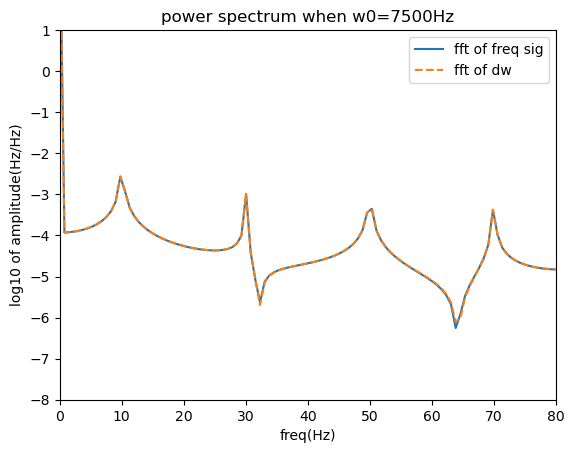

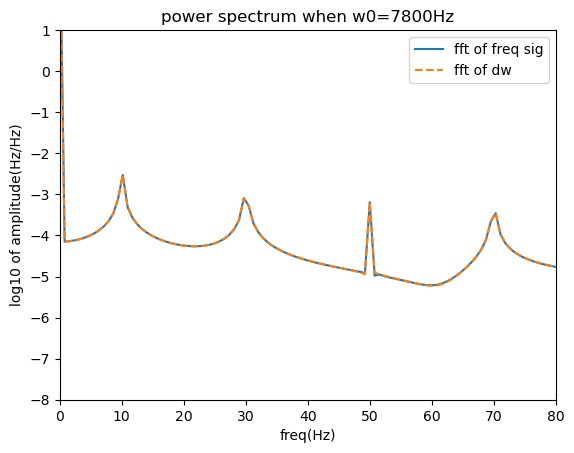

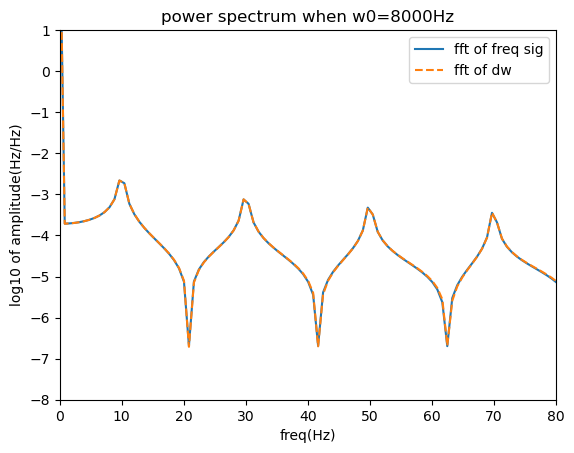

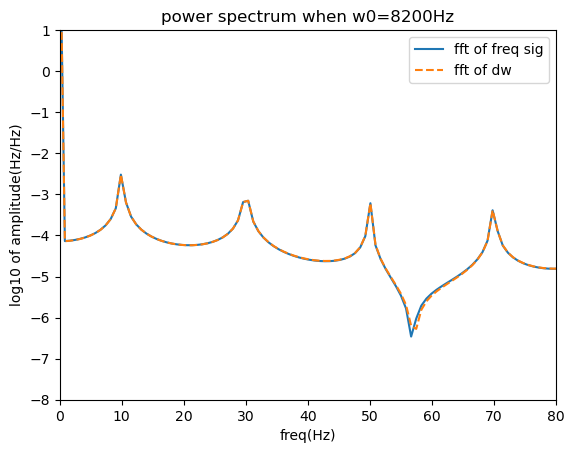

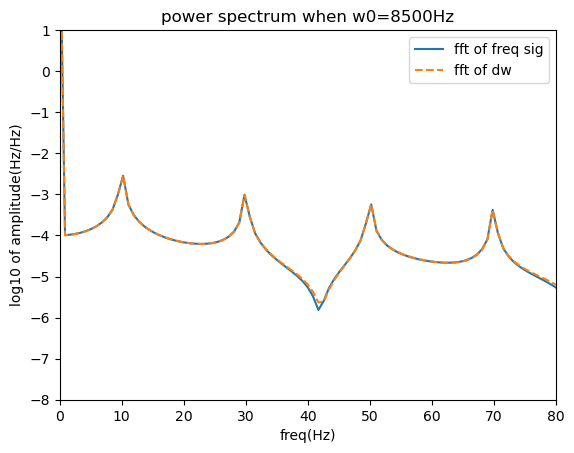

In [33]:
freq_freqShift=10 # the freq of freq shift(Hz)

dtau = 0.05*2*np.pi #our sampling rate is about 200kHz, w0 is about 8k, so about 20 times bigger
n = 10000.3 # number of cycles in each pulse, making simulation time to be 1s
tau_l = np.arange(0,len(dw_l)*dtau,dtau)
X0_0 = [1,0]# initial displacement and velocity for simulation
Q=20000
w0_l = [7500*2*np.pi,7800*2*np.pi,8000*2*np.pi,8200*2*np.pi,8500*2*np.pi]


for w0 in w0_l:
    dw = 0.01/w0*2*np.pi# we need to set the efficient rad freq for eacxh set, w_eff = 1+dw, and real rad freq w(t) = w0*w_eff = w0*(1+dw)\

    pulse_length = 1/freq_freqShift/2*w0 # the length of the pulse is the period of the freq shift, note that tau = t*w0
    dw_l = square_pulse(tau_l,dtau,pulse_length,dw)
    dw_l_sim = np.array([dw_l,np.append(dw_l[1:],dw_l[-1]),np.append(dw_l[1:],dw_l[-1]),np.append(dw_l[1:],dw_l[-1])]).T
    F = np.zeros((len(dw_l),4))
    t_l =tau_l/w0
    signal_freqShift = bs.solve_RK4(X0_0, dtau, Q, F,dw_l_sim)

    t_rip = 10e-4# s, time of the ripple of our signal
    t_cycle = 1e-4# s, time of the window cycle of our signal
    dt_chunk_target =  0.05*2*np.pi*10/w0#s, target chunk time of the frequency signal
    t_freqshift_l = np.arange(0,len(signal_freqShift[:,0])*dtau/w0,dtau/w0)
    data = np.array([t_freqshift_l,signal_freqShift[:,0]]).T

    freq_sig = getCantileverFreq(data,t_cycle,0,dt_chunk_target)
    t_freq_signal = np.arange(0,len(freq_sig)*dt_chunk_target,dt_chunk_target)

    sig_f_fft = np.fft.fft(freq_sig[i_ripp_sig:-i_ripp_sig])
    sig_f_fft_abs = sig_f_fft / len(freq_sig[i_ripp_sig:-i_ripp_sig])
    sig_f_fft_freqs = np.fft.fftfreq(len(freq_sig[i_ripp_sig:-i_ripp_sig]), d=dt_chunk_target)

    dw_fft = np.fft.fft(dw_l[i_ripp_fs:-i_ripp_fs]*w0/2/np.pi+w0/2/np.pi)
    dw_fft_abs = dw_fft / len(dw_l[i_ripp_fs:-i_ripp_fs]*w0/2/np.pi+w0/2/np.pi)
    dw_fft_freqs = np.fft.fftfreq(len(dw_l[i_ripp_fs:-i_ripp_fs]*w0/2/np.pi+w0/2/np.pi), d=dtau/w0)

    plt.plot(sig_f_fft_freqs[:len(sig_f_fft_freqs)//2],np.log10(np.abs(sig_f_fft_abs)[:len(sig_f_fft_freqs)//2]),label='fft of freq sig')
    plt.plot(dw_fft_freqs[:len(dw_fft_freqs)//2],np.log10(np.abs(dw_fft_abs[:len(dw_fft_freqs)//2])),label = 'fft of dw',linestyle = '--')

    plt.xlim(0,freq_freqShift*8)
    plt.ylim(-8,1)
    plt.xlabel('freq(Hz)')
    plt.ylabel('log10 of amplitude(Hz/Hz)')
    plt.legend()
    plt.title('power spectrum when w0=' + format(w0/2/np.pi, '.4g') + 'Hz')
    plt.show()